#### IMPORTS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import os
import sys
sys.path.append('../src')
from preprocess import clean_text

LOAD DATA

In [5]:
df = pd.read_csv('../data/Reviews.csv')
print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


#### CLEAN AND LABEL DATA

In [6]:
# Drop neutral reviews, nulls and duplicates
df = df[df['Score'] != 3]
df.dropna(subset=['Text'], inplace=True)
df.drop_duplicates(subset=['Text'], inplace=True)

# Create binary sentiment label
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)
print(df['sentiment'].value_counts())

sentiment
1    306766
0     57070
Name: count, dtype: int64


#### VISUALISE CLASS BALANCE AND REVIEW LENGHTS

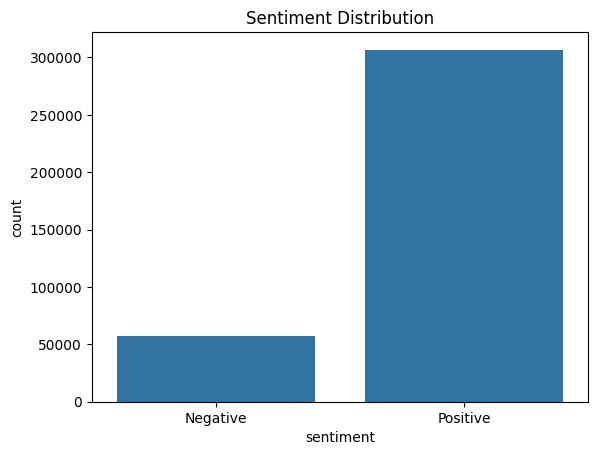

In [7]:
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.savefig('../data/sentiment_distribution.png')
plt.show()

#### WORD CLOUDS

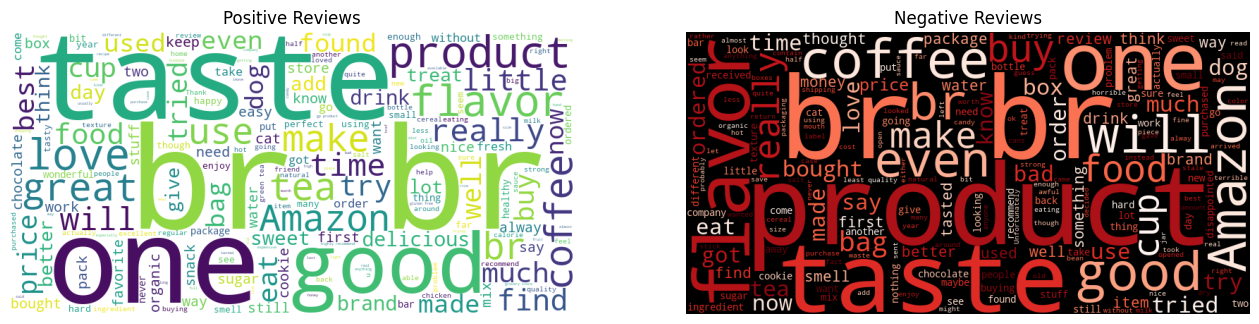

In [8]:
positive_text = ' '.join(df[df['sentiment']==1]['Text'].sample(5000, random_state=42))
negative_text = ' '.join(df[df['sentiment']==0]['Text'].sample(5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

axes[0].imshow(wc_pos)
axes[0].set_title('Positive Reviews')
axes[0].axis('off')

axes[1].imshow(wc_neg)
axes[1].set_title('Negative Reviews')
axes[1].axis('off')

plt.savefig('../data/wordclouds.png')
plt.show()

APPLY CLEANING AND SPLIT DATA

In [9]:
from sklearn.model_selection import train_test_split

df['clean_text'] = df['Text'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 291068 | Test: 72768


#### TF-IDF vectorisation

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

TRAIN LOGISTIC REGRESSION

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

y_pred = model_lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79     11414
           1       0.95      0.98      0.96     61354

    accuracy                           0.94     72768
   macro avg       0.91      0.85      0.88     72768
weighted avg       0.94      0.94      0.94     72768



#### CONFUSION MATRIX

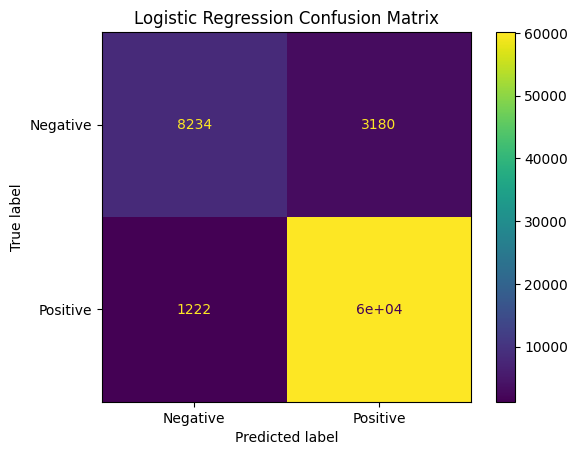

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negative', 'Positive']
)
plt.title('Logistic Regression Confusion Matrix')
plt.savefig('../data/confusion_matrix_lr.png')
plt.show()

#### SAVE MODELS

In [13]:
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(model_lr, '../models/logistic_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("Models saved successfully.")

Models saved successfully.
